In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

#### import SARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima

In [2]:
cities=['Paris']
city    = cities[0]

In [3]:
LOOKBACK = 6
NUM_SERV=5
EPOCHS=100
B=1
ALPHAS=[0.75,2,3,5]
ALPHA=ALPHAS[1]

In [ ]:
bordeaux = pd.read_csv(f'/home/sergi_alcala/sergi_data/AZTEC_extension/citys/{city}.csv',parse_dates=True, index_col="date_time")
bordeaux.index = pd.to_datetime(bordeaux.index)
bordeaux = bordeaux.asfreq('6min')

In [7]:
y = bordeaux['Deezer'].values

In [8]:
y = bordeaux['Deezer'].values
y = y[~np.isnan(y)]

In [18]:
y_train = y[:int(len(y)*0.8)]
y_test = y[int(len(y)*0.8):]

In [12]:
y_train=y_train[:500]

In [19]:
model = auto_arima(
    y_train,
    seasonal=True,
    m=244,                  # Seasonality = 288 for daily cycle in 5-minute data
    stepwise=False,          # Speeds up search using heuristic
    max_order=10,          # Total of p+q+P+Q ≤ 10
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    suppress_warnings=True,
    trace=True,              # Shows progress
    n_jobs=-1
)

 ARIMA(0,1,0)(0,0,0)[244] intercept   : AIC=637721.398, Time=0.43 sec
 ARIMA(1,1,0)(0,0,0)[244] intercept   : AIC=637720.982, Time=0.86 sec
 ARIMA(0,1,1)(0,0,0)[244] intercept   : AIC=637721.543, Time=1.30 sec
 ARIMA(2,1,0)(0,0,0)[244] intercept   : AIC=637383.576, Time=1.36 sec
 ARIMA(0,1,2)(0,0,0)[244] intercept   : AIC=637461.443, Time=2.08 sec
 ARIMA(2,1,1)(0,0,0)[244] intercept   : AIC=636458.814, Time=4.98 sec
 ARIMA(1,1,2)(0,0,0)[244] intercept   : AIC=636250.782, Time=5.38 sec
 ARIMA(1,1,1)(0,0,0)[244] intercept   : AIC=636985.063, Time=6.87 sec
 ARIMA(2,1,2)(0,0,0)[244] intercept   : AIC=635946.846, Time=10.37 sec
 ARIMA(0,1,0)(1,0,0)[244] intercept   : AIC=637713.240, Time=1425.97 sec
 ARIMA(0,1,0)(0,0,1)[244] intercept   : AIC=637713.401, Time=1671.90 sec
 ARIMA(1,1,0)(1,0,0)[244] intercept   : AIC=637713.259, Time=2058.26 sec
 ARIMA(0,1,1)(1,0,0)[244] intercept   : AIC=637713.716, Time=2274.02 sec
 ARIMA(1,1,0)(0,0,1)[244] intercept   : AIC=637713.412, Time=2406.54 sec


: 

In [15]:
print(model.summary())



                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  500
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 244)   Log Likelihood              -10908.606
Date:                             Fri, 28 Mar 2025   AIC                          21827.211
Time:                                     14:19:17   BIC                          21848.274
Sample:                                          0   HQIC                         21835.477
                                             - 500                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.758e+07   8.02e-12  -2.19e+18      0.000   -1.76e+07   -1.76e+07
ar.L1         -0.2705      

In [16]:
# Forecast next 240 steps (i.e., one day)
forecast = model.predict(n_periods=len(y_test))

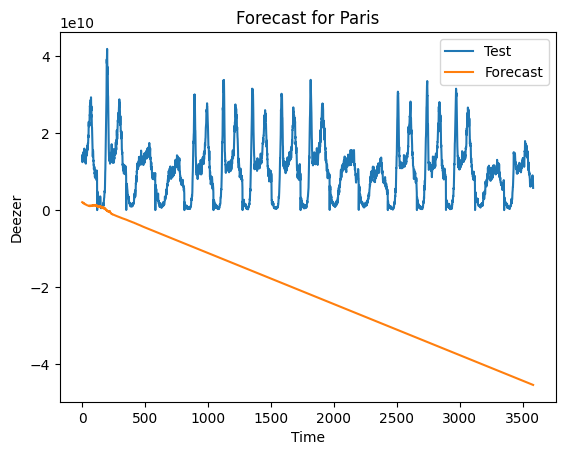

In [17]:
plt.plot(y_test, label='Test')
plt.plot(forecast, label='Forecast')
plt.title(f'Forecast for {city}')
plt.xlabel('Time')
plt.ylabel('Deezer')
plt.legend()

In [8]:
bordeaux

,Deezer,Twitter,Netflix,DailyMotion,Google
date_time,,,,,
2019-03-16 00:00:00,7.661295e+09,4.984221e+09,1.913365e+10,3.715763e+09,1.003533e+10
2019-03-16 00:06:00,8.498106e+09,5.524231e+09,2.693565e+10,5.987104e+09,1.194084e+10
2019-03-16 00:12:00,7.840178e+09,5.007678e+09,2.228499e+10,6.016507e+09,1.082493e+10
2019-03-16 00:18:00,7.324067e+09,5.175788e+09,2.517854e+10,4.996462e+09,1.142234e+10
2019-03-16 00:24:00,6.965789e+09,4.674172e+09,2.535136e+10,5.302894e+09,1.125597e+10
...,...,...,...,...,...
2019-05-31 23:30:00,7.471209e+09,5.695090e+09,2.834518e+10,4.897072e+09,1.923148e+10
2019-05-31 23:36:00,6.800559e+09,5.832772e+09,2.626166e+10,4.985933e+09,1.748572e+10
2019-05-31 23:42:00,6.601630e+09,6.006835e+09,2.550989e+10,4.994673e+09,1.863934e+10


In [4]:
## Load Data

bordeaux = pd.read_csv(f'/home/sergi_alcala/sergi_data/AZTEC_extension/citys/{city}.csv')
bordeaux.drop('date_time', axis=1, inplace=True)
bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
bordeaux = bordeaux.to_numpy()

XTRAIN=round(len(bordeaux)*0.8)
DELAY=1


In [5]:
## Normalize Data
minmaxscaler = MinMaxScaler()
x_train = bordeaux[:XTRAIN]
# x_train_norm = minmaxscaler.fit_transform(x_train)
x_test = bordeaux[XTRAIN:]
# x_test_norm = minmaxscaler.transform(x_test)

In [6]:
x_train_serv_0 = x_train[:,0]
x_test_serv_0 = x_test[:,0]

In [ ]:
# model = auto_arima(x_train_norm, seasonal=True, m=7, stepwise=True, suppress_warnings=True, error_action="ignore", max_order=None, trace=True)
model = auto_arima(x_train_serv_0, seasonal=True,m=240, stepwise=False, suppress_warnings=True,trace = True)



 ARIMA(0,1,0)(0,0,0)[240] intercept   : AIC=629954.857, Time=0.60 sec
 ARIMA(0,1,0)(0,0,1)[240] intercept   : AIC=629941.404, Time=1483.83 sec


In [10]:
forecasts = model.predict(len(x_test))
# forecasts = model.predict(len(x_test), return_conf_int=True, alpha=0.05)

In [13]:
forecasts

array([5.92726441e+09, 5.91662441e+09, 5.91669536e+09, ...,
       6.17048997e+09, 6.17056093e+09, 6.17063188e+09])

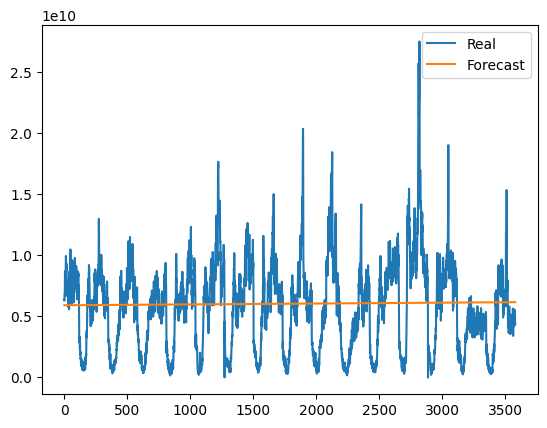

In [12]:
plt.plot(x_test_serv_0, label='Real')
plt.plot(forecasts, label='Forecast')
plt.legend()

In [14]:
### Create model SARIMA

model = SARIMAX(x_train_norm[:,0])
model_fit = model.fit(disp=False)


In [15]:
y = model_fit.forecast(steps=len(x_test_norm))
y = y.reshape(-1,1)

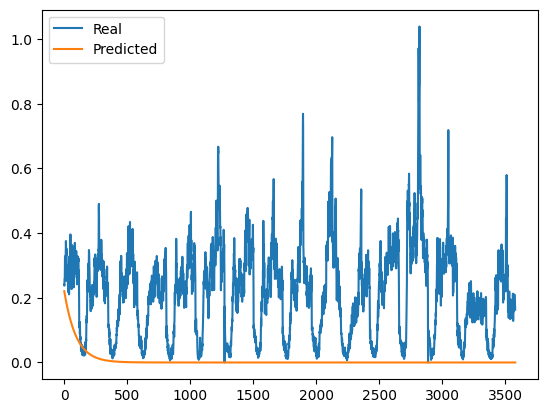

In [16]:
#plot results

plt.plot(x_test_norm[:,0], label='Real')
plt.plot(y, label='Predicted')
plt.legend()